## Automated Incident Report Generation
**Project:** Windows Log Intelligence: Anomaly Detection & Incident Reporting  

### What We Do Here
1. Load anomaly records
2. Build a **structured anomaly summary**
3. Use **HuggingFace Flan-T5** (instruction-tuned) to generate:
   - Impact Assessment
   - Root Cause Analysis
   - Remediation Recommendations
4. Assemble and export a **full Incident Report**
5. Visualise the final anomaly dashboard

> **Model Used:** `google/flan-t5-base` — runs locally, no API key required.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import joblib
import os
import warnings
from datetime import datetime

from transformers import pipeline, AutoTokenizer, AutoModelForSeq2SeqLM
warnings.filterwarnings('ignore')

sns.set_theme(style='darkgrid')
plt.rcParams.update({'figure.dpi': 130})

os.makedirs('../reports', exist_ok=True)

HF_MODEL_NAME  = 'google/flan-t5-base'
MAX_NEW_TOKENS = 512



### Load Configuration and Data

In [2]:


# Load anomaly results
df_all      = pd.read_csv('../data/processed/metadata_labeled.csv')
df_anomaly  = pd.read_csv('../data/anomalies/anomalies.csv')
errors      = np.load('../data/processed/reconstruction_errors.npy')
thresh_data = joblib.load('../models/autoencoder/threshold.pkl')

threshold   = thresh_data['threshold']

print(f'Total records    : {len(df_all):,}')
print(f'Anomaly records  : {len(df_anomaly):,}')
print(f'Anomaly rate     : {len(df_anomaly)/len(df_all)*100:.2f}%')
print(f'Threshold        : {threshold:.6f}')
df_anomaly.head(3)

Total records    : 158,184
Anomaly records  : 7,905
Anomaly rate     : 5.00%
Threshold        : 1.997532


,#,MachineName,Category,EntryType,Source,TimeGenerated,country,regionName,city,isp,reconstruction_error,anomaly_score,is_anomaly,severity
0,24,LAPTOP-1MKMTVPM,General,Information,ESENT,2020-11-14 07:21:00,India,Gujarat,Ahmedabad,GTPL A. J. Enterprise,2.726558,0.060310,True,LOW
1,40,LAPTOP-1MKMTVPM,Logging/Recovery,Information,ESENT,2020-11-14 07:21:00,India,Gujarat,Ahmedabad,GTPL A. J. Enterprise,3.520774,0.077917,True,LOW
2,92,LAPTOP-1MKMTVPM,Logging/Recovery,Information,ESENT,2020-11-14 17:45:00,India,Gujarat,Ahmedabad,GTPL A. J. Enterprise,3.507622,0.077625,True,LOW


### Build Anomaly Summary Dictionary


Compiles all key statistics into a structured Python dict that will be fed into the AI model, including total records, anomaly rate, severity breakdown, top affected machines, top log sources, and top countries involved.

In [11]:
def build_summary(df_all, df_anomaly, errors, threshold):
  

    def safe_value_counts(df, col, n=5):
        """Return value counts dict, or empty dict if column missing."""
        if col not in df.columns:
            print(f" Warning: column '{col}' not found — skipping.")
            return {}
        return df[col].value_counts().head(n).to_dict()

    def safe_mean(df, col):
        """Return column mean, or None if column missing."""
        if col not in df.columns:
            return None
        return float(df[col].mean())

    summary = {
        # Core stats
        'total_records'         : len(df_all),
        'total_anomalies'       : len(df_anomaly),
        'anomaly_rate_pct'      : round(len(df_anomaly) / len(df_all) * 100, 2) if len(df_all) > 0 else 0.0,
        'threshold'             : round(float(threshold), 6),

        # Error stats
        'max_error'             : round(float(errors.max()), 6),
        'min_error'             : round(float(errors.min()), 6),
        'mean_error_all'        : round(float(errors.mean()), 6),
        'std_error_all'         : round(float(errors.std()), 6),       
        'mean_error_anomalies'  : round(safe_mean(df_anomaly, 'reconstruction_error') or 0, 6),

        # Severity 
        'severity_breakdown'    : safe_value_counts(df_anomaly, 'severity', n=10),

        # Top offenders 
        'top_anomaly_sources'   : safe_value_counts(df_anomaly, 'Source'),
        'top_anomaly_machines'  : safe_value_counts(df_anomaly, 'MachineName'),
        'top_anomaly_countries' : safe_value_counts(df_anomaly, 'country'),
        'top_entry_types'       : safe_value_counts(df_anomaly, 'EntryType'),
        'top_categories'        : safe_value_counts(df_anomaly, 'Category'),
        'top_isps'              : safe_value_counts(df_anomaly, 'isp'),

        # Time range (useful for report header)
        'date_range_start'      : str(df_all['TimeGenerated'].min()) if 'TimeGenerated' in df_all.columns else 'N/A',
        'date_range_end'        : str(df_all['TimeGenerated'].max()) if 'TimeGenerated' in df_all.columns else 'N/A',
    }

    return summary


# Run & print─
summary = build_summary(df_all, df_anomaly, errors, threshold)

print('Anomaly Summary:')
print('-' * 55)
for k, v in summary.items():
    print(f'  {k:<28}: {v}')

# Validation check
print('\nValidation:')
assert summary['total_anomalies'] <= summary['total_records'], " More anomalies than total records!"
assert 0 <= summary['anomaly_rate_pct'] <= 100, " Anomaly rate out of range!"
assert summary['threshold'] > 0," Threshold must be positive!"
print(" All checks passed")

Anomaly Summary:
-------------------------------------------------------
  total_records               : 158184
  total_anomalies             : 7905
  anomaly_rate_pct            : 5.0
  threshold                   : 1.997532
  max_error                   : 45.114037
  min_error                   : 0.006101
  mean_error_all              : 0.433904
  std_error_all               : 1.388016
  mean_error_anomalies        : 3.497024
  severity_breakdown          : {'LOW': 7784, 'CRITICAL': 120, 'MEDIUM': 1}
  top_anomaly_sources         : {'ESENT': 7173, 'Software Protection Platform Service': 410, 'Windows Error Reporting': 255, 'MsiInstaller': 58, 'System Restore': 4}
  top_anomaly_machines        : {'LAPTOP-1MKMTVPM': 4137, 'TMP249-G3-M': 2926, 'DESKTOP-SEJ28PM': 421, 'DESKTOP-R5JMQHG': 229, 'DESKTOP-U66O8IT': 95}
  top_anomaly_countries       : {'India': 7905}
  top_entry_types             : {'Information': 7903, '0': 1, 'Warning': 1}
  top_categories              : {'General': 4787, 'L

### Load HuggingFace Model


Load a Local LLM (Flan-T5)
Downloads and loads google/flan-t5-base from HuggingFace — a 247 million parameter instruction-tuned model that runs entirely locally with no API key. This is used to generate the natural language sections of the report.

In [12]:
print(f'Loading model: {HF_MODEL_NAME} ...')

tokenizer = AutoTokenizer.from_pretrained(HF_MODEL_NAME)
model     = AutoModelForSeq2SeqLM.from_pretrained(HF_MODEL_NAME)

llm = pipeline(
    'text2text-generation',
    model=model,
    tokenizer=tokenizer,
    max_new_tokens=MAX_NEW_TOKENS
)

print(f'Model loaded: {HF_MODEL_NAME}')
print(f'   Parameters : {sum(p.numel() for p in model.parameters()):,}')

Loading model: google/flan-t5-base ...


Device set to use cpu


Model loaded: google/flan-t5-base
   Parameters : 247,577,856


### Define LLM Prompt Builders

- Executive Summary — for the CISO
- Impact Assessment — operational, data, reputational risk
- Root Cause Analysis — why did these anomalies happen?
Remediation Steps — what to do, in priority order P1/P2/P3

In [14]:
def llm_generate(prompt: str) -> str:
    """Call the LLM and return generated text."""
    try:
        result = llm(prompt, max_new_tokens=MAX_NEW_TOKENS)
        return result[0]['generated_text'].strip()
    except Exception as e:
        return f'[LLM generation failed: {e}]'


def prompt_impact(s):
    return (
        f"You are a cybersecurity analyst. Assess the business impact of this "
        f"Windows security incident: "
        f"{s['anomaly_rate_pct']}% anomaly rate ({s['total_anomalies']} events out of {s['total_records']}), "
        f"severity breakdown: {s['severity_breakdown']}, "
        f"top affected machines: {list(s['top_anomaly_machines'].keys())[:3]}, "
        f"top countries involved: {list(s['top_anomaly_countries'].keys())[:3]}. "
        f"Provide a 3-sentence impact assessment covering operational, data, and reputational risk."
    )


def prompt_root_cause(s, df_anomaly):
    top_msgs = df_anomaly.nlargest(3, 'reconstruction_error')['Message'] \
                         .fillna('').str[:120].tolist() if 'Message' in df_anomaly.columns else []
    msg_sample = ' | '.join(top_msgs)
    return (
        f"As a Windows security expert, identify possible root causes for these anomalies: "
        f"Top event sources: {list(s['top_anomaly_sources'].keys())[:3]}, "
        f"categories: {list(s['top_categories'].keys())[:3]}, "
        f"entry types with highest anomaly rate: {s['top_entry_types']}, "
        f"sample high-error log messages: {msg_sample}. "
        f"List the 3 most likely root causes concisely with one sentence each."
    )


def prompt_remediation(s):
    return (
        f"As a senior Windows system administrator, provide remediation steps for a security incident: "
        f"anomaly rate {s['anomaly_rate_pct']}%, "
        f"top anomalous sources: {list(s['top_anomaly_sources'].keys())[:3]}, "
        f"severity distribution: {s['severity_breakdown']}, "
        f"countries involved: {list(s['top_anomaly_countries'].keys())[:3]}. "
        f"Give 4 numbered, actionable remediation steps with priority level (P1/P2/P3)."
    )


def prompt_executive_summary(s):
    return (
        f"Write a 2-sentence executive summary for a CISO about a Windows security anomaly detection report: "
        f"{s['total_anomalies']:,} anomalies detected ({s['anomaly_rate_pct']}% rate), "
        f"highest severity: {list(s['severity_breakdown'].keys())[0] if s['severity_breakdown'] else 'Unknown'}, "
        f"from {len(s['top_anomaly_countries'])} countries. Keep it professional and concise."
    )


print('Prompt builders defined')

Prompt builders defined


### Generate LLM Sections

In [15]:
print('Generating LLM sections... \n')

print('Executive Summary...')
exec_summary  = llm_generate(prompt_executive_summary(summary))
print(f'  → {exec_summary[:120]}...\n')

print('Impact Assessment...')
impact_text   = llm_generate(prompt_impact(summary))
print(f'  → {impact_text[:120]}...\n')

print('Root Cause Analysis...')
root_cause    = llm_generate(prompt_root_cause(summary, df_anomaly))
print(f'  → {root_cause[:120]}...\n')

print('Remediation...')
remediation   = llm_generate(prompt_remediation(summary))
print(f'  → {remediation[:120]}...\n')

print('All LLM sections generated!')

Generating LLM sections... 

Executive Summary...
  → Windows security anomaly detection report: 7,905 anomalies detected (5.0% rate), highest severity: LOW, from 1 countries...

Impact Assessment...
  → This Windows security incident occurred in India. The top affected machines were ['Laptops-1MKMTVPM', 'TMP249-G3-M', 'DE...

Root Cause Analysis...
  → Logging/Recovery 0 Logging/Recovery 0 Logging/Recovery 0 Logging/Recovery 0 Logging/Recovery 0 Logging/Recovery 0 Loggin...

Remediation...
  → A security incident in India involved an anomaly rate of 5.0%, top anomalous sources: ['ESENT', 'Software Protection Pla...

All LLM sections generated!


### Assemble Full Incident Report

In [16]:
def format_dict(d: dict, indent=2) -> str:
    pad = ' ' * indent
    if not d: return f'{pad}(none)'
    return '\n'.join(f'{pad}{str(k):<35} {v:>6}' for k, v in d.items())


def format_top_anomalies(df, n=5):
    cols  = ['MachineName','Source','EntryType','severity','reconstruction_error']
    avail = [c for c in cols if c in df.columns]
    top   = df.nlargest(n, 'reconstruction_error')[avail]
    lines = []
    for i, (_, row) in enumerate(top.iterrows(), 1):
        lines.append(f'  [{i}] ' + ' | '.join(f'{c}: {row[c]}' for c in avail))
    return '\n'.join(lines) if lines else '  (none)'


def interpret_error(max_err, thresh):
    ratio = max_err / (thresh + 1e-8)
    if ratio > 10:   return 'EXTREME'
    elif ratio > 5:  return 'VERY HIGH'
    elif ratio > 2:  return 'HIGH'
    else:            return 'MODERATE'


timestamp   = datetime.now().strftime('%Y-%m-%d %H:%M:%S')
incident_id = datetime.now().strftime('INC-%Y%m%d-%H%M%S')
s           = summary

report = f"""
================================================================================
                    WINDOWS SECURITY INCIDENT REPORT
================================================================================
Incident ID    : {incident_id}
Generated At   : {timestamp}
Classification : {'CRITICAL' if 'CRITICAL' in s['severity_breakdown'] else 'HIGH'}
Detection      : Autoencoder Anomaly Detection (PyTorch)
Status         : OPEN — Pending Investigation
================================================================================

EXECUTIVE SUMMARY
─────────────────────────────────────────────────────────────────────
{exec_summary}

QUANTITATIVE OVERVIEW
─────────────────────────────────────────────────────────────────────
  Total Events Analyzed       : {s['total_records']:,}
  Anomalies Detected          : {s['total_anomalies']:,}
  Anomaly Rate                : {s['anomaly_rate_pct']}%
  Detection Threshold (MSE)   : {s['threshold']:.6f}
  Max Reconstruction Error    : {s['max_error']:.6f}  [{interpret_error(s['max_error'], s['threshold'])} deviation]
  Mean Error (All)            : {s['mean_error_all']:.6f}
  Mean Error (Anomalies)      : {s['mean_error_anomalies']:.6f}

SEVERITY BREAKDOWN
─────────────────────────────────────────────────────────────────────
{format_dict(s['severity_breakdown'])}

TOP AFFECTED MACHINES
─────────────────────────────────────────────────────────────────────
{format_dict(s['top_anomaly_machines'])}

TOP ANOMALOUS EVENT SOURCES
─────────────────────────────────────────────────────────────────────
{format_dict(s['top_anomaly_sources'])}

ENTRY TYPE DISTRIBUTION (Anomalies)
─────────────────────────────────────────────────────────────────────
{format_dict(s['top_entry_types'])}

CATEGORY BREAKDOWN (Anomalies)
─────────────────────────────────────────────────────────────────────
{format_dict(s['top_categories'])}

GEOGRAPHIC DISTRIBUTION
─────────────────────────────────────────────────────────────────────
{format_dict(s['top_anomaly_countries'])}

ISP / NETWORK ORIGIN
─────────────────────────────────────────────────────────────────────
{format_dict(s['top_isps'])}

IMPACT ASSESSMENT  [AI-Generated — Flan-T5]
─────────────────────────────────────────────────────────────────────
{impact_text}

ROOT CAUSE ANALYSIS  [AI-Generated — Flan-T5]
─────────────────────────────────────────────────────────────────────
{root_cause}

REMEDIATION RECOMMENDATIONS  [AI-Generated — Flan-T5]
─────────────────────────────────────────────────────────────────────
{remediation}

TOP CRITICAL ANOMALY RECORDS
─────────────────────────────────────────────────────────────────────
{format_top_anomalies(df_anomaly, n=5)}

DETECTION METHODOLOGY
─────────────────────────────────────────────────────────────────────
  Model            : Symmetric Autoencoder (PyTorch)
  Architecture     : Input → 128 → 64 → 32 → 16 ← 32 ← 64 ← 128 ← Input
  Training Mode    : Unsupervised (learns normal behaviour)
  Anomaly Metric   : Per-sample MSE reconstruction error
  Threshold Policy : {thresh_data['percentile']}th percentile of training errors
  Feature Groups   : Temporal (13) + Categorical LE (9) + TF-IDF (50) + Msg Stats (7)
  LLM Narrative    : {HF_MODEL_NAME} (HuggingFace Transformers)

================================================================================
                          END OF INCIDENT REPORT
================================================================================
""".strip()

print(report[:3000])
print('\n... [truncated for notebook display]')

                    WINDOWS SECURITY INCIDENT REPORT
Incident ID    : INC-20260222-182922
Generated At   : 2026-02-22 18:29:22
Classification : CRITICAL
Detection      : Autoencoder Anomaly Detection (PyTorch)
Status         : OPEN — Pending Investigation

EXECUTIVE SUMMARY
─────────────────────────────────────────────────────────────────────
Windows security anomaly detection report: 7,905 anomalies detected (5.0% rate), highest severity: LOW, from 1 countries

QUANTITATIVE OVERVIEW
─────────────────────────────────────────────────────────────────────
  Total Events Analyzed       : 158,184
  Anomalies Detected          : 7,905
  Anomaly Rate                : 5.0%
  Detection Threshold (MSE)   : 1.997532
  Max Reconstruction Error    : 45.114037  [EXTREME deviation]
  Mean Error (All)            : 0.433904
  Mean Error (Anomalies)      : 3.497024

SEVERITY BREAKDOWN
─────────────────────────────────────────────────────────────────────
  LOW                                   7784
  CRI

### Save Report to File

In [17]:
report_filename = f'../reports/incident_{datetime.now().strftime("%Y%m%d_%H%M%S")}.txt'

with open(report_filename, 'w', encoding='utf-8') as f:
    f.write(report)

print(f'Full incident report saved: {report_filename}')
print(f'   File size: {os.path.getsize(report_filename) / 1024:.1f} KB')

Full incident report saved: ../reports/incident_20260222_183025.txt
   File size: 9.1 KB


### Final Anomaly Dashboard

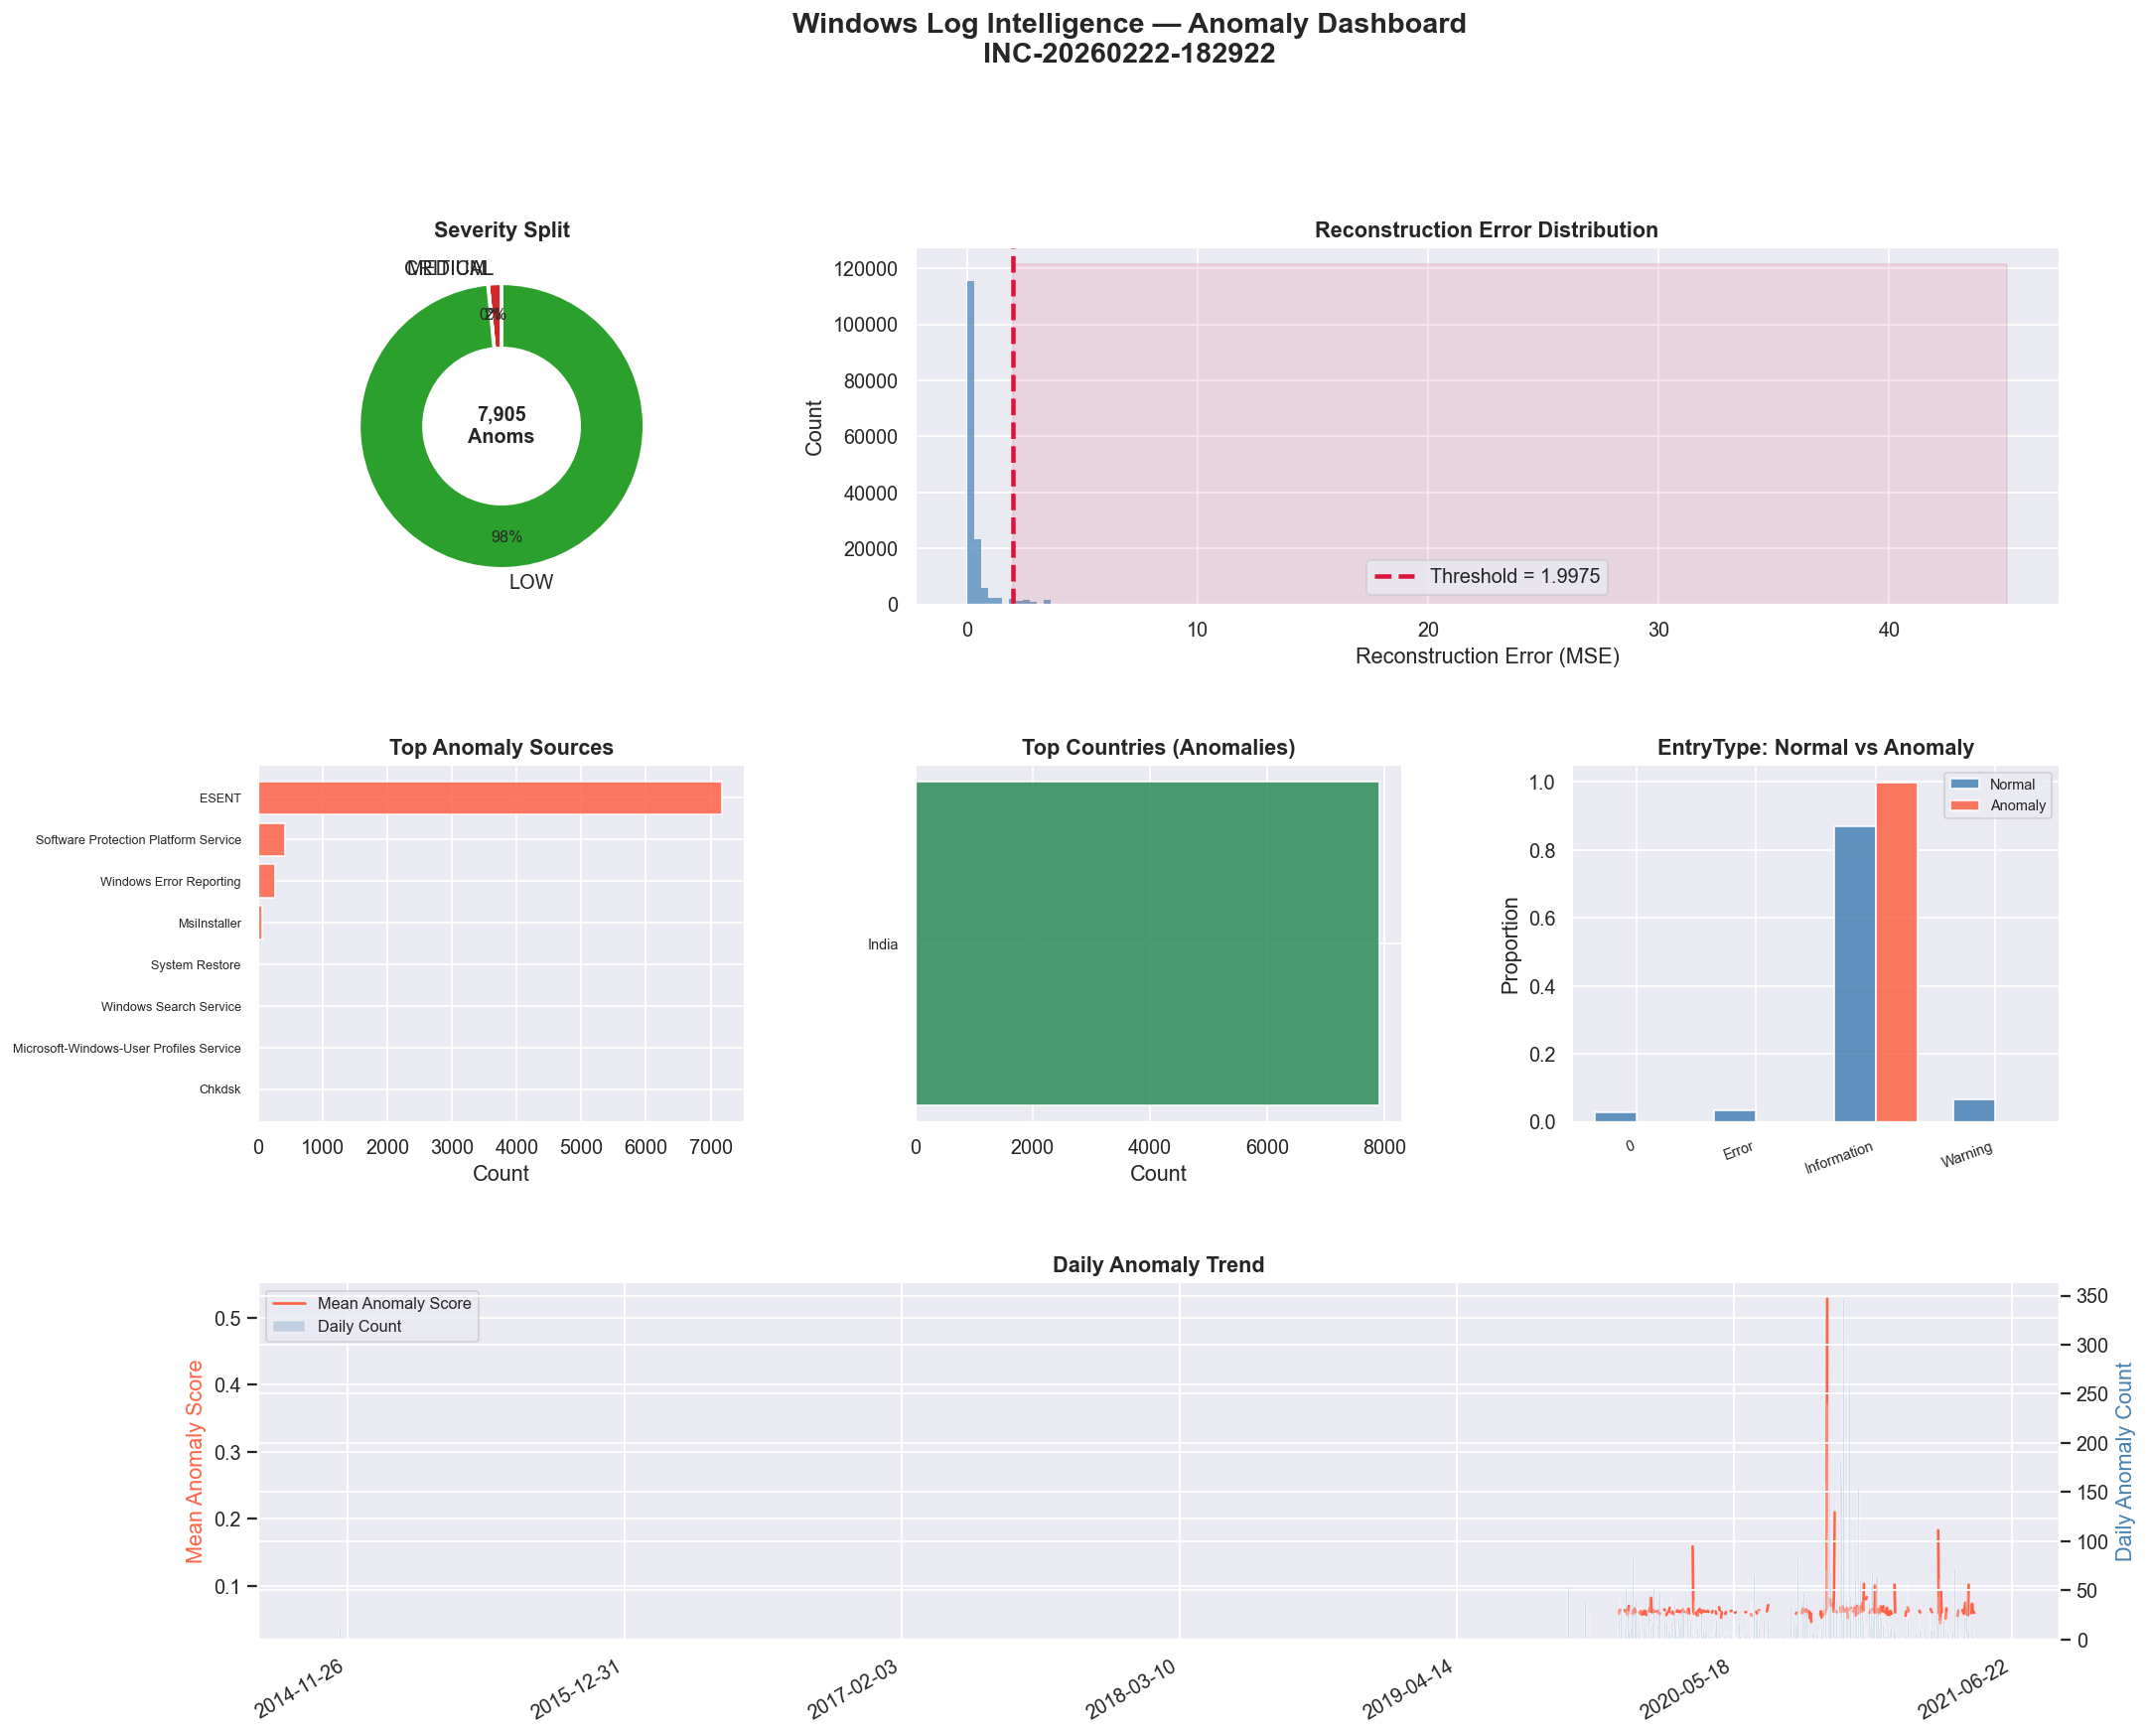

Dashboard saved: ../reports/final_dashboard.png


In [20]:
import matplotlib.ticker as mticker


fig = plt.figure(figsize=(18, 14))
fig.suptitle(f'Windows Log Intelligence — Anomaly Dashboard\n{incident_id}',
             fontsize=16, fontweight='bold', y=1.01)

gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

# ── 1. Severity Donut ─────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])

color_map  = {'CRITICAL': '#d62728', 'HIGH': '#ff7f0e',
              'MEDIUM':   '#ffbf00', 'LOW':  '#2ca02c'}

sev_counts = (
    df_anomaly['severity']
    .value_counts()
    .reindex(['CRITICAL', 'HIGH', 'MEDIUM', 'LOW'])
    .fillna(0)           # ← fix: replace NaN with 0
    .astype(int)
)
sev_counts = sev_counts[sev_counts > 0]          # ← drop zero-count levels
colors_sev = [color_map[s] for s in sev_counts.index]

wedges, _, autotexts = ax1.pie(
    sev_counts,
    labels     = sev_counts.index,
    autopct    = '%1.0f%%',
    colors     = colors_sev,
    wedgeprops = {'edgecolor': 'white', 'linewidth': 2},
    startangle = 90,
    pctdistance= 0.78
)
for at in autotexts:
    at.set_fontsize(9)

circle = plt.Circle((0, 0), 0.55, fc='white')
ax1.add_artist(circle)
ax1.text(0, 0, f'{len(df_anomaly):,}\nAnoms', ha='center', va='center',
         fontsize=11, fontweight='bold')
ax1.set_title('Severity Split', fontweight='bold')

# ── 2. Error Distribution ─────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1:])
ax2.hist(errors, bins=150, color='steelblue', alpha=0.7, edgecolor='none')
ax2.axvline(threshold, color='crimson', lw=2.5, linestyle='--',
            label=f'Threshold = {threshold:.4f}')
_, ymax = ax2.get_ylim()
ax2.fill_betweenx([0, ymax if ymax > 0 else 1000],
                  threshold, errors.max(), alpha=0.1, color='crimson')
ax2.set_xlabel('Reconstruction Error (MSE)')
ax2.set_ylabel('Count')
ax2.set_title('Reconstruction Error Distribution', fontweight='bold')
ax2.legend()

# ── 3. Top Sources ────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 0])
top_src = df_anomaly['Source'].value_counts().head(8)
ax3.barh(top_src.index[::-1], top_src.values[::-1], color='tomato', alpha=0.85)
ax3.set_title('Top Anomaly Sources', fontweight='bold')
ax3.set_xlabel('Count')
ax3.tick_params(axis='y', labelsize=7)

# ── 4. Top Countries ──────────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 1])
top_cty = df_anomaly['country'].value_counts().head(8)
ax4.barh(top_cty.index[::-1], top_cty.values[::-1], color='seagreen', alpha=0.85)
ax4.set_title('Top Countries (Anomalies)', fontweight='bold')
ax4.set_xlabel('Count')
ax4.tick_params(axis='y', labelsize=8)

# ── 5. EntryType: Normal vs Anomaly ──────────────────────────────
ax5 = fig.add_subplot(gs[1, 2])
normal_et  = df_all[~df_all['is_anomaly']]['EntryType'].value_counts(normalize=True)
anomaly_et = df_anomaly['EntryType'].value_counts(normalize=True)
all_et     = sorted(set(normal_et.index) | set(anomaly_et.index))
x_pos      = np.arange(len(all_et))
w          = 0.35
ax5.bar(x_pos - w/2, [normal_et.get(e, 0) for e in all_et],
        width=w, label='Normal',  color='steelblue', alpha=0.85)
ax5.bar(x_pos + w/2, [anomaly_et.get(e, 0) for e in all_et],
        width=w, label='Anomaly', color='tomato',    alpha=0.85)
ax5.set_xticks(x_pos)
ax5.set_xticklabels(all_et, rotation=20, ha='right', fontsize=8)
ax5.set_ylabel('Proportion')
ax5.set_title('EntryType: Normal vs Anomaly', fontweight='bold')
ax5.legend(fontsize=8)

# ── 6. Daily Anomaly Trend ────────────────────────────────────────
ax6 = fig.add_subplot(gs[2, :])
if 'TimeGenerated' in df_anomaly.columns:
    df_anomaly['TimeGenerated'] = pd.to_datetime(df_anomaly['TimeGenerated'], errors='coerce')
    df_anomaly_t  = df_anomaly.set_index('TimeGenerated')
    daily_anomaly = df_anomaly_t.resample('D')['anomaly_score'].agg(['mean', 'count'])

    ax6.plot(daily_anomaly.index, daily_anomaly['mean'],
             color='tomato', lw=1.5, label='Mean Anomaly Score')
    ax6b = ax6.twinx()
    ax6b.bar(daily_anomaly.index, daily_anomaly['count'],
             alpha=0.25, color='steelblue', label='Daily Count', width=0.8)
    ax6b.set_ylabel('Daily Anomaly Count', color='steelblue')
    ax6.set_ylabel('Mean Anomaly Score',   color='tomato')
    ax6.set_title('Daily Anomaly Trend',   fontweight='bold')
    ax6.xaxis.set_major_locator(mticker.MaxNLocator(8))
    plt.setp(ax6.xaxis.get_majorticklabels(), rotation=30, ha='right')

    lines1, labels1 = ax6.get_legend_handles_labels()
    lines2, labels2 = ax6b.get_legend_handles_labels()
    ax6.legend(lines1 + lines2, labels1 + labels2, fontsize=9, loc='upper left')
else:
    ax6.text(0.5, 0.5, 'TimeGenerated not available',
             ha='center', va='center', transform=ax6.transAxes, fontsize=12)

plt.savefig('../reports/final_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print('Dashboard saved: ../reports/final_dashboard.png')

### Inspect Top Critical Anomalies

In [21]:
# Show top 10 highest-error events with key columns
display_cols = [c for c in ['MachineName','Source','EntryType','Category',
                             'country','severity','anomaly_score',
                             'reconstruction_error','TimeGenerated']
                if c in df_anomaly.columns]

top10 = df_anomaly.nlargest(10, 'reconstruction_error')[display_cols]

print('Top 10 Highest Reconstruction Error Events:')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
display(top10.reset_index(drop=True))

Top 10 Highest Reconstruction Error Events:


,MachineName,Source,EntryType,Category,country,severity,anomaly_score,reconstruction_error,TimeGenerated
0,LAPTOP-1MKMTVPM,Windows Error Reporting,Information,0,India,CRITICAL,1.000000,45.114037,2020-09-29 15:11:00
1,LAPTOP-1MKMTVPM,Windows Error Reporting,Information,0,India,CRITICAL,0.999794,45.104740,2020-09-29 15:11:00
2,LAPTOP-1MKMTVPM,Windows Error Reporting,Information,0,India,CRITICAL,0.999756,45.103035,2020-09-29 15:11:00
3,LAPTOP-1MKMTVPM,Windows Error Reporting,Information,0,India,CRITICAL,0.999720,45.101418,2020-09-29 15:11:00
4,LAPTOP-1MKMTVPM,Windows Error Reporting,Information,0,India,CRITICAL,0.999688,45.099957,2020-09-29 15:11:00
5,LAPTOP-1MKMTVPM,Windows Error Reporting,Information,0,India,CRITICAL,0.999561,45.094246,2020-09-29 15:11:00
6,LAPTOP-1MKMTVPM,Windows Error Reporting,Information,0,India,CRITICAL,0.999038,45.070640,2020-09-29 15:11:00
7,LAPTOP-1MKMTVPM,Windows Error Reporting,Information,0,India,CRITICAL,0.998907,45.064740,2020-09-29 15:11:00
8,LAPTOP-1MKMTVPM,Windows Error Reporting,Information,0,India,CRITICAL,0.998831,45.061325,2020-09-29 15:11:00
9,LAPTOP-1MKMTVPM,Windows Error Reporting,Information,0,India,CRITICAL,0.998795,45.059677,2020-09-29 15:11:00


In [22]:
# Show top CRITICAL anomaly messages
if 'Message' in df_anomaly.columns:
    print('Sample CRITICAL Anomaly Messages:\n')
    critical = df_anomaly[df_anomaly['severity'] == 'CRITICAL'].nlargest(3, 'reconstruction_error')
    for i, (_, row) in enumerate(critical.iterrows(), 1):
        print(f'[{i}] Source: {row.get("Source","N/A")} | '
              f'Machine: {row.get("MachineName","N/A")} | '
              f'Error: {row["reconstruction_error"]:.4f}')
        print(f'     Message: {str(row["Message"])[:300]}')
        print()

### Project Summary

In [24]:

print('DETECTION RESULTS:')
print(f'  Total Records    : {summary["total_records"]:,}')
print(f'  Anomalies Found  : {summary["total_anomalies"]:,} ({summary["anomaly_rate_pct"]}%)')
print(f'  Critical         : {summary["severity_breakdown"].get("CRITICAL", 0):,}')
print(f'  High             : {summary["severity_breakdown"].get("HIGH", 0):,}')
print(f'  Medium           : {summary["severity_breakdown"].get("MEDIUM", 0):,}')
print(f'  Low              : {summary["severity_breakdown"].get("LOW", 0):,}')


DETECTION RESULTS:
  Total Records    : 158,184
  Anomalies Found  : 7,905 (5.0%)
  Critical         : 120
  High             : 0
  Medium           : 1
  Low              : 7,784
